In [1]:
!pip install yfinance pandas numpy

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# List of LQ45 stocks
lq45_stocks = ['AALI.JK', 'ACES.JK', 'ADRO.JK', 'AKRA.JK', 'AMMN.JK', 'AMRT.JK', 'ANTM.JK', 'ARTO.JK', 'ASII.JK', 'BBCA.JK', 'BBNI.JK', 'BBRI.JK', 'BBTN.JK', 'BMRI.JK', 'BRPT.JK', 'BRIS.JK', 'BSDE.JK', 'BTPS.JK', 'BUMI.JK', 'CPIN.JK', 'CTRA.JK', 'DSSA.JK', 'EMTK.JK', 'ERAA.JK', 'EXCL.JK', 'GGRM.JK', 'GOTO.JK', 'HEAL.JK', 'HMSP.JK', 'ICBP.JK', 'INCO.JK', 'INDF.JK', 'INDY.JK', 'INKP.JK', 'INTP.JK', 'ITMG.JK', 'JSMR.JK', 'KLBF.JK', 'LPKR.JK', 'LPPF.JK', 'MAPA.JK', 'MBMA.JK', 'MDKA.JK', 'MEDC.JK', 'MIKA.JK', 'MNCN.JK', 'MTEL.JK', 'NCKL.JK', 'PGAS.JK', 'PGEO.JK', 'PTBA.JK', 'PTMP.JK', 'PTPP.JK', 'PWON.JK', 'SCMA.JK', 'SMGR.JK', 'SMRA.JK', 'SRIL.JK', 'SSMS.JK', 'TBIG.JK', 'TKIM.JK', 'TINS.JK', 'TLKM.JK', 'TOWR.JK', 'UNTR.JK', 'UNVR.JK', 'WIKA.JK', 'WSBP.JK', 'WSKT.JK', 'WTON.JK']

hidiv_stocks = [
    'ADRO.JK', 'BSSR.JK', 'PTBA.JK', 'ITMG.JK', 'LPPF.JK',
    'GEMS.JK', 'UNTR.JK', 'TOTL.JK', 'HEXA.JK', 'MCOL.JK',
    'MPMX.JK', 'PANS.JK', 'TAPG.JK', 'POWR.JK', 'DLTA.JK',
    'BJBR.JK', 'SPTO.JK', 'BJTM.JK', 'AMAG.JK', 'CLPI.JK',
    'PBID.JK', 'ADMF.JK', 'ASDM.JK', 'EPMT.JK'
]

In [ ]:
print("=" * 80)
print("CORRELATION ANALYSIS (5-YEAR TIMEFRAME)")
print("=" * 80)
print(f"\nTotal stocks to analyze: {len(hidiv_stocks)}")
print(f"Timeframe: {datetime.now() - timedelta(days=5*365)} to {datetime.now()}")
print("\nDownloading stock data...")

# Download 5 years of data
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

# Download data for all stocks
data = yf.download(hidiv_stocks, start=start_date, end=end_date, progress=False)['Close']

# Remove stocks with insufficient data (less than 80% of trading days)
min_data_points = len(data) * 0.8
valid_stocks = data.columns[data.count() >= min_data_points].tolist()
data = data[valid_stocks]

print(f"Stocks with sufficient data: {len(valid_stocks)}")
print(f"Stocks excluded due to insufficient data: {len(hidiv_stocks) - len(valid_stocks)}")

if len(hidiv_stocks) - len(valid_stocks) > 0:
    excluded = set(hidiv_stocks) - set(valid_stocks)
    print(f"Excluded stocks: {', '.join(sorted(excluded))}")

# Calculate daily returns
returns = data.pct_change().dropna()

# Calculate correlation matrix
print("\nCalculating correlation matrix...")
correlation_matrix = returns.corr()

# Find most correlated pairs
print("\n" + "=" * 80)
print("TOP 10 MOST CORRELATED STOCK PAIRS")
print("=" * 80)

# Get upper triangle of correlation matrix (to avoid duplicates)
upper_triangle = np.triu(correlation_matrix, k=1)
correlation_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        stock1 = correlation_matrix.columns[i]
        stock2 = correlation_matrix.columns[j]
        corr_value = correlation_matrix.iloc[i, j]
        correlation_pairs.append((stock1, stock2, corr_value))

# Sort by correlation (descending)
correlation_pairs.sort(key=lambda x: x[2], reverse=True)

# Print top 10 most correlated
for idx, (stock1, stock2, corr) in enumerate(correlation_pairs[:10], 1):
    print(f"{idx:2d}. {stock1:10s} <-> {stock2:10s} | Correlation: {corr:7.4f}")

# Find least correlated pairs
print("\n" + "=" * 80)
print("TOP 10 LEAST CORRELATED STOCK PAIRS")
print("=" * 80)

# Sort by absolute correlation (ascending) to find least correlated
correlation_pairs_abs = [(s1, s2, corr, abs(corr)) for s1, s2, corr in correlation_pairs]
correlation_pairs_abs.sort(key=lambda x: x[3])

# Print top 10 least correlated
for idx, (stock1, stock2, corr, abs_corr) in enumerate(correlation_pairs_abs[:10], 1):
    print(f"{idx:2d}. {stock1:10s} <-> {stock2:10s} | Correlation: {corr:7.4f}")

# Summary statistics
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

all_correlations = [corr for _, _, corr in correlation_pairs]
print(f"Average correlation: {np.mean(all_correlations):.4f}")
print(f"Median correlation:  {np.median(all_correlations):.4f}")
print(f"Std dev correlation: {np.std(all_correlations):.4f}")
print(f"Min correlation:     {np.min(all_correlations):.4f}")
print(f"Max correlation:     {np.max(all_correlations):.4f}")

print("\n" + "=" * 80)
print("Analysis complete!")
print("=" * 80)

CORRELATION ANALYSIS (5-YEAR TIMEFRAME)

Total stocks to analyze: 24
Timeframe: 2021-02-09 16:30:16.589421 to 2026-02-08 16:30:16.589453



/tmp/ipython-input-2081636942.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(hidiv_stocks, start=start_date, end=end_date, progress=False)['Close']


Stocks with sufficient data: 24
Stocks excluded due to insufficient data: 0

Calculating correlation matrix...

TOP 10 MOST CORRELATED STOCK PAIRS
 1. ITMG.JK    <-> PTBA.JK    | Correlation:  0.5759
 2. ADRO.JK    <-> ITMG.JK    | Correlation:  0.5155
 3. ADRO.JK    <-> PTBA.JK    | Correlation:  0.4937
 4. BJBR.JK    <-> BJTM.JK    | Correlation:  0.4849
 5. PTBA.JK    <-> UNTR.JK    | Correlation:  0.4414
 6. ADRO.JK    <-> UNTR.JK    | Correlation:  0.4372
 7. ITMG.JK    <-> UNTR.JK    | Correlation:  0.4336
 8. BSSR.JK    <-> ITMG.JK    | Correlation:  0.3716
 9. ADRO.JK    <-> BSSR.JK    | Correlation:  0.3419
10. BSSR.JK    <-> PTBA.JK    | Correlation:  0.3202

TOP 10 LEAST CORRELATED STOCK PAIRS
 1. AMAG.JK    <-> HEXA.JK    | Correlation: -0.0027
 2. MCOL.JK    <-> MPMX.JK    | Correlation:  0.0060
 3. MCOL.JK    <-> PANS.JK    | Correlation:  0.0069
 4. GEMS.JK    <-> MCOL.JK    | Correlation: -0.0077
 5. MCOL.JK    <-> POWR.JK    | Correlation: -0.0078
 6. CLPI.JK    <-> MC

In [ ]:
print("=" * 100)
print("INDIVIDUAL STOCK CORRELATION ANALYSIS (5-YEAR TIMEFRAME)")
print("=" * 100)
print(f"\nTotal stocks to analyze: {len(hidiv_stocks)}")
print(f"Timeframe: {(datetime.now() - timedelta(days=5*365)).strftime('%Y-%m-%d')} to {datetime.now().strftime('%Y-%m-%d')}")
print("\nDownloading stock data... (this may take a moment)")

# Download 5 years of data
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

# Download data for all stocks
try:
    data = yf.download(hidiv_stocks, start=start_date, end=end_date, progress=False)['Adj Close']
except Exception as e:
    print(f"Error downloading data: {e}")
    exit(1)

# Handle single column case (if only one stock)
if isinstance(data, pd.Series):
    data = data.to_frame()

# Remove any columns that are entirely NaN
data = data.dropna(axis=1, how='all')

# Remove stocks with insufficient data (less than 80% of trading days)
min_data_points = len(data) * 0.8
valid_stocks = [col for col in data.columns if data[col].count() >= min_data_points]
data = data[valid_stocks]

# Forward fill and backward fill to handle minor gaps
data = data.ffill().bfill()

print(f"\nStocks with sufficient data: {len(valid_stocks)}")
print(f"Stocks excluded due to insufficient data: {len(lq45_stocks) - len(valid_stocks)}")

if len(lq45_stocks) - len(valid_stocks) > 0:
    excluded = set(lq45_stocks) - set(valid_stocks)
    print(f"Excluded stocks: {', '.join(sorted(excluded))}")

# Calculate daily returns
returns = data.pct_change().dropna()

# Remove any remaining NaN or infinite values
returns = returns.replace([np.inf, -np.inf], np.nan).dropna()

# Calculate correlation matrix
print("\nCalculating correlation matrix...")
correlation_matrix = returns.corr()

# Remove any rows/columns that are all NaN
correlation_matrix = correlation_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')

# Update valid_stocks to only include stocks in correlation matrix
valid_stocks = correlation_matrix.columns.tolist()

print("\n" + "=" * 100)
print("MOST AND LEAST CORRELATED STOCKS FOR EACH STOCK")
print("=" * 100)

# For each stock, find most and least correlated
results = []

for stock in sorted(valid_stocks):
    try:
        # Get correlations for this stock (excluding itself)
        stock_corrs = correlation_matrix[stock].drop(stock)

        # Remove any NaN values
        stock_corrs = stock_corrs.dropna()

        if len(stock_corrs) == 0:
            continue

        # Most correlated (highest positive)
        most_corr_stock = stock_corrs.idxmax()
        most_corr_value = stock_corrs.max()

        # Least correlated (lowest absolute value)
        least_corr_stock = stock_corrs.abs().idxmin()
        least_corr_value = stock_corrs[least_corr_stock]

        results.append({
            'stock': stock,
            'most_corr_with': most_corr_stock,
            'most_corr_value': most_corr_value,
            'least_corr_with': least_corr_stock,
            'least_corr_value': least_corr_value
        })
    except Exception as e:
        print(f"Warning: Could not process {stock}: {e}")
        continue

# Print results in a formatted table
print(f"\n{'Stock':<12} | {'Most Correlated With':<20} | {'Corr':<7} | {'Least Correlated With':<20} | {'Corr':<7}")
print("-" * 100)

for result in results:
    print(f"{result['stock']:<12} | {result['most_corr_with']:<20} | {result['most_corr_value']:>6.4f} | "
          f"{result['least_corr_with']:<20} | {result['least_corr_value']:>6.4f}")

# Additional analysis - count how many times each stock appears
print("\n" + "=" * 100)
print("SUMMARY: STOCKS THAT APPEAR MOST FREQUENTLY")
print("=" * 100)

# Count most correlated appearances
most_corr_counter = {}
for result in results:
    stock = result['most_corr_with']
    most_corr_counter[stock] = most_corr_counter.get(stock, 0) + 1

print("\nMost Frequently Appearing as 'Most Correlated':")
print(f"{'Stock':<12} | {'Count':<5} | {'Description'}")
print("-" * 60)
for stock, count in sorted(most_corr_counter.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{stock:<12} | {count:<5} | Highly correlated with {count} other stocks")

# Count least correlated appearances
least_corr_counter = {}
for result in results:
    stock = result['least_corr_with']
    least_corr_counter[stock] = least_corr_counter.get(stock, 0) + 1

print("\nMost Frequently Appearing as 'Least Correlated':")
print(f"{'Stock':<12} | {'Count':<5} | {'Description'}")
print("-" * 60)
for stock, count in sorted(least_corr_counter.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{stock:<12} | {count:<5} | Independent from {count} other stocks")

# Overall statistics
print("\n" + "=" * 100)
print("OVERALL STATISTICS")
print("=" * 100)

all_most_corr = [r['most_corr_value'] for r in results]
all_least_corr = [r['least_corr_value'] for r in results]

print(f"\nMost Correlated Pairs:")
print(f"  Average:  {np.mean(all_most_corr):.4f}")
print(f"  Median:   {np.median(all_most_corr):.4f}")
print(f"  Range:    {np.min(all_most_corr):.4f} to {np.max(all_most_corr):.4f}")

print(f"\nLeast Correlated Pairs:")
print(f"  Average:  {np.mean(all_least_corr):.4f}")
print(f"  Median:   {np.median(all_least_corr):.4f}")
print(f"  Range:    {np.min(all_least_corr):.4f} to {np.max(all_least_corr):.4f}")

print("\n" + "=" * 100)
print("Analysis complete!")
print("=" * 100)

INDIVIDUAL STOCK CORRELATION ANALYSIS (5-YEAR TIMEFRAME)

Total stocks to analyze: 24
Timeframe: 2021-02-09 to 2026-02-08



/tmp/ipython-input-1085999181.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(hidiv_stocks, start=start_date, end=end_date, progress=False)['Adj Close']


Error downloading data: 'Adj Close'

Stocks with sufficient data: 24
Stocks excluded due to insufficient data: 46
Excluded stocks: AALI.JK, ACES.JK, AKRA.JK, AMMN.JK, AMRT.JK, ANTM.JK, ARTO.JK, ASII.JK, BBCA.JK, BBNI.JK, BBRI.JK, BBTN.JK, BMRI.JK, BRIS.JK, BRPT.JK, BSDE.JK, BTPS.JK, BUMI.JK, CPIN.JK, CTRA.JK, DSSA.JK, EMTK.JK, ERAA.JK, EXCL.JK, GGRM.JK, GOTO.JK, HEAL.JK, HMSP.JK, ICBP.JK, INCO.JK, INDF.JK, INDY.JK, INKP.JK, INTP.JK, JSMR.JK, KLBF.JK, LPKR.JK, MAPA.JK, MBMA.JK, MDKA.JK, MEDC.JK, MIKA.JK, MNCN.JK, MTEL.JK, NCKL.JK, PGAS.JK, PGEO.JK, PTMP.JK, PTPP.JK, PWON.JK, SCMA.JK, SMGR.JK, SMRA.JK, SRIL.JK, SSMS.JK, TBIG.JK, TINS.JK, TKIM.JK, TLKM.JK, TOWR.JK, UNVR.JK, WIKA.JK, WSBP.JK, WSKT.JK, WTON.JK

Calculating correlation matrix...

MOST AND LEAST CORRELATED STOCKS FOR EACH STOCK

Stock        | Most Correlated With | Corr    | Least Correlated With | Corr   
----------------------------------------------------------------------------------------------------
ADMF.JK      | PTBA

Fetching data for ADRO.JK vs 24 stocks...


[*********************100%***********************]  24 of 24 completed
/tmp/ipython-input-10203533.py:28: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().dropna()



Correlation Table: How stocks move relative to ADRO.JK
------------------------------------------------------------
         Correlation       Relationship
Ticker                                 
ADRO.JK     1.000000    Strong Positive
ITMG.JK     0.515457  Moderate Positive
PTBA.JK     0.493066  Moderate Positive
UNTR.JK     0.438322  Moderate Positive
BSSR.JK     0.341594  Moderate Positive
HEXA.JK     0.229278       Uncorrelated
GEMS.JK     0.215152       Uncorrelated
BJBR.JK     0.193609       Uncorrelated
TAPG.JK     0.178361       Uncorrelated
BJTM.JK     0.171043       Uncorrelated
PANS.JK     0.142534       Uncorrelated
DLTA.JK     0.140605       Uncorrelated
LPPF.JK     0.131671       Uncorrelated
PBID.JK     0.104960       Uncorrelated
MPMX.JK     0.097169       Uncorrelated
CLPI.JK     0.094429       Uncorrelated
EPMT.JK     0.093541       Uncorrelated
TOTL.JK     0.087211       Uncorrelated
ADMF.JK     0.076169       Uncorrelated
ASDM.JK     0.075810       Uncorrelated
POW

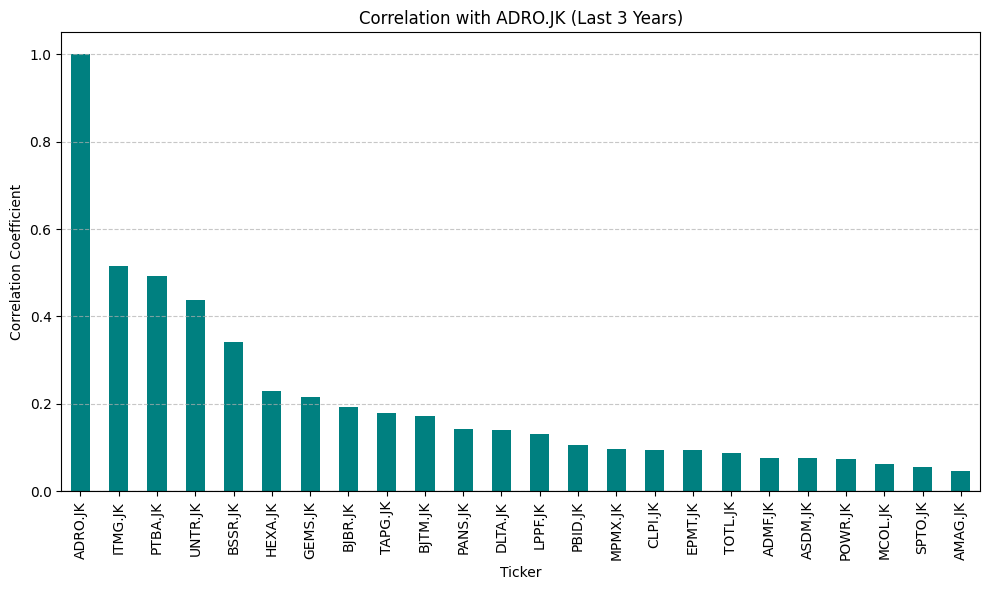

In [4]:
# 1. Configuration
# The stock you want to compare everything else against
target_ticker = 'ADRO.JK'

# The list of stocks to compare with (from your previous request)
comparison_tickers = [
    'ADRO.JK', 'BSSR.JK', 'PTBA.JK', 'ITMG.JK', 'LPPF.JK',
    'GEMS.JK', 'UNTR.JK', 'TOTL.JK', 'HEXA.JK', 'MCOL.JK',
    'MPMX.JK', 'PANS.JK', 'TAPG.JK', 'POWR.JK', 'DLTA.JK',
    'BJBR.JK', 'SPTO.JK', 'BJTM.JK', 'AMAG.JK', 'CLPI.JK',
    'PBID.JK', 'ADMF.JK', 'ASDM.JK', 'EPMT.JK'
]

# (Optional) Add the target to the list if it's not there, to download all data at once
all_tickers = list(set([target_ticker] + comparison_tickers))

def get_correlation_against_target(target, tickers, years=5):
    print(f"Fetching data for {target} vs {len(tickers)} stocks...")

    # 2. Fetch Data
    end_date = datetime.today()
    start_date = end_date - timedelta(days=years*365)

    # Download 'Adj Close'
    data = yf.download(all_tickers, start=start_date, end=end_date, auto_adjust=True)['Close']

    # 3. Calculate Returns
    returns = data.pct_change().dropna()

    # 4. separate Target Returns and Universe Returns
    target_returns = returns[target]
    universe_returns = returns[tickers]

    # 5. Calculate Correlation (Series)
    # .corrwith() calculates correlation pairwise between the series and the dataframe
    correlations = universe_returns.corrwith(target_returns)

    # 6. Create a nice Table
    corr_df = correlations.to_frame(name='Correlation')

    # Add interpretation column
    def interpret(x):
        if x > 0.7: return "Strong Positive"
        elif x > 0.3: return "Moderate Positive"
        elif x > -0.3: return "Uncorrelated"
        elif x > -0.7: return "Moderate Negative"
        else: return "Strong Negative"

    corr_df['Relationship'] = corr_df['Correlation'].apply(interpret)

    # Sort by Correlation (High to Low)
    return corr_df.sort_values(by='Correlation', ascending=False)

# --- EXECUTION ---
df_result = get_correlation_against_target(target_ticker, comparison_tickers)

print(f"\nCorrelation Table: How stocks move relative to {target_ticker}")
print("-" * 60)
print(df_result)

# Optional: Plotting as a bar chart
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 6))
    # Plot bars
    df_result['Correlation'].plot(kind='bar', color='teal')

    plt.title(f'Correlation with {target_ticker} (Last 3 Years)')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.ylabel('Correlation Coefficient')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
except ImportError:
    pass